AI 빅데이터학과 

20211461 최성민 / 20211463 최우혁

In [1]:
!pip install kagglehub


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool, cpu_count
from pathlib import Path
import numpy as np



c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


캐글에 있는 데이터 다운받기

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jorijnsmit/binance-full-history")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\jorijnsmit\binance-full-history\versions\41


데이터 로드

In [3]:
import os
import pandas as pd
import time  

# 경로
output_dir = "symbol_parquet"
os.makedirs(output_dir, exist_ok=True)

# parquet 파일 목록
parquet_files = [f for f in os.listdir(path) if f.endswith(".parquet")]

start_time = time.time()  # 작업 시작 시간 기록

# 파일별 순차 처리
for f in parquet_files:
    try:
        file_path = os.path.join(path, f)
        df = pd.read_parquet(file_path)

        # open_time이 인덱스라면 컬럼으로 복원
        if df.index.name == "open_time":
            df = df.reset_index()

        # symbol 컬럼 추가
        df['symbol'] = f.replace(".parquet", "")

        # 저장 경로
        out_path = os.path.join(output_dir, f)

        # open_time 포함된 상태로 저장 (컬럼으로), 인덱스는 제거
        df.to_parquet(out_path, index=False)

        print(f" 저장 완료: {f}")

    except Exception as e:
        print(f" {f} 에러: {e}")

end_time = time.time()  # 작업 종료 시간 기록
elapsed_time = end_time - start_time
print(f"\n전체 작업 소요 시간: {elapsed_time:.2f}초")


 저장 완료: 1INCH-BTC.parquet
 저장 완료: 1INCH-BUSD.parquet
 저장 완료: 1INCH-USDT.parquet
 저장 완료: AAVE-BNB.parquet
 저장 완료: AAVE-BTC.parquet
 저장 완료: AAVE-BUSD.parquet
 저장 완료: AAVE-ETH.parquet
 저장 완료: AAVE-USDT.parquet
 저장 완료: ACM-USDT.parquet
 저장 완료: ADA-AUD.parquet
 저장 완료: ADA-BNB.parquet
 저장 완료: ADA-BRL.parquet
 저장 완료: ADA-BTC.parquet
 저장 완료: ADA-BUSD.parquet
 저장 완료: ADA-ETH.parquet
 저장 완료: ADA-EUR.parquet
 저장 완료: ADA-GBP.parquet
 저장 완료: ADA-TRY.parquet
 저장 완료: ADA-TUSD.parquet
 저장 완료: ADA-USDC.parquet
 저장 완료: ADA-USDT.parquet
 저장 완료: ADADOWN-USDT.parquet
 저장 완료: ADAUP-USDT.parquet
 저장 완료: ADX-BTC.parquet
 저장 완료: ADX-ETH.parquet
 저장 완료: AE-BTC.parquet
 저장 완료: AE-ETH.parquet
 저장 완료: AERGO-BUSD.parquet
 저장 완료: AGI-BTC.parquet
 저장 완료: AION-BNB.parquet
 저장 완료: AION-BTC.parquet
 저장 완료: AION-ETH.parquet
 저장 완료: AION-USDT.parquet
 저장 완료: AKRO-USDT.parquet
 저장 완료: ALGO-BNB.parquet
 저장 완료: ALGO-BTC.parquet
 저장 완료: ALGO-BUSD.parquet
 저장 완료: ALGO-USDT.parquet
 저장 완료: ALICE-BTC.parquet
 저장 완료: ALICE-BUSD.p

In [4]:
# 저장된 폴더 경로
input_dir = "symbol_parquet"
files = [f for f in os.listdir(input_dir) if f.endswith(".parquet")]

# 기준 날짜
cutoff_date = pd.Timestamp("2022-10-01")

# 결과 리스트
df_list = []

for f in files:
    try:
        file_path = os.path.join(input_dir, f)
        df = pd.read_parquet(file_path)

        # 날짜 변환
        if 'open_time' in df.columns:
            df['open_time'] = pd.to_datetime(df['open_time'])

            # 2022-10-01 이후 데이터 필터링
            df_filtered = df[df['open_time'] >= cutoff_date]

            if not df_filtered.empty:
                df_list.append(df_filtered)

                print(f" 포함: {f} | {len(df_filtered)} rows")

            else:
                print(f" 제외: {f} (2022-10-01 이후 데이터 없음)")

        else:
            print(f" 제외: {f} (open_time 없음)")

    except Exception as e:
        print(f" {f} 에러: {e}")

# 전체 병합
combined_df = pd.concat(df_list, ignore_index=True)
print(f"\n 병합 완료: 총 {combined_df.shape[0]} rows")

# 필요시 저장
combined_df.to_parquet("filtered_combined.parquet", index=False)


 포함: 1INCH-BTC.parquet | 67680 rows
 포함: 1INCH-BUSD.parquet | 67680 rows
 포함: 1INCH-USDT.parquet | 67680 rows
 포함: AAVE-BNB.parquet | 67674 rows
 포함: AAVE-BTC.parquet | 67680 rows
 포함: AAVE-BUSD.parquet | 67680 rows
 포함: AAVE-ETH.parquet | 67680 rows
 포함: AAVE-USDT.parquet | 67680 rows
 포함: ACM-USDT.parquet | 67680 rows
 포함: ADA-AUD.parquet | 67680 rows
 포함: ADA-BNB.parquet | 67680 rows
 포함: ADA-BRL.parquet | 67680 rows
 포함: ADA-BTC.parquet | 67680 rows
 포함: ADA-BUSD.parquet | 67680 rows
 포함: ADA-ETH.parquet | 67680 rows
 포함: ADA-EUR.parquet | 67680 rows
 포함: ADA-GBP.parquet | 67680 rows
 포함: ADA-TRY.parquet | 67680 rows
 제외: ADA-TUSD.parquet (2022-10-01 이후 데이터 없음)
 제외: ADA-USDC.parquet (2022-10-01 이후 데이터 없음)
 포함: ADA-USDT.parquet | 67680 rows
 포함: ADADOWN-USDT.parquet | 67680 rows
 포함: ADAUP-USDT.parquet | 67580 rows
 포함: ADX-BTC.parquet | 67680 rows
 포함: ADX-ETH.parquet | 67680 rows
 제외: AE-BTC.parquet (2022-10-01 이후 데이터 없음)
 제외: AE-ETH.parquet (2022-10-01 이후 데이터 없음)
 포함: AERGO-BUSD.

코인 데이터는 시계열 데이터 중에서도 변동성이 심한 데이터입니다. 너무 긴 시계열 데이터는 오히려 노이즈로 작용한다고 판단합니다.

이예 따라 마지막 1달(2022-10-01) 이후 데이터만 가져와서 사용했습니다

이상치 클러스터링

Isolation Forest으로 이상치 탐지

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df = pd.read_parquet("filtered_combined.parquet")

# 파생 변수 생성
features_iso = pd.DataFrame({
    'price_change': df['close'].pct_change(),
    'vol_z': (df['volume'] - df['volume'].mean()) / df['volume'].std(),
    'volatility': (df['high'] - df['low']) / df['open']
})

# NaN, inf 값 제거
features_iso = features_iso.replace([np.inf, -np.inf], np.nan)
features_iso_clean = features_iso.dropna()

# 원본 df에서도 동일한 인덱스로 정렬
df_clean = df.iloc[features_iso_clean.index]

# 정규화
X_scaled = StandardScaler().fit_transform(features_iso_clean)

# Isolation Forest
clf = IsolationForest(contamination=0.01, random_state=42)
iso_pred = clf.fit_predict(X_scaled)

# 이상치 추출
iso_anomalies = df_clean[iso_pred == -1].copy()
iso_anomalies.reset_index(drop=True, inplace=True)

print(f" Isolation Forest가 탐지한 이상 거래 수: {len(iso_anomalies)}")


 Isolation Forest가 탐지한 이상 거래 수: 545534


클러스터링

In [6]:
df=iso_anomalies

In [7]:
df.head(1)

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,symbol
0,2022-10-07 12:50:00,0.000029,0.00003,0.000029,0.00003,5458.399902,0.161617,71,3623.699951,0.10717,1INCH-BTC


In [8]:
def iqr_filter(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

# 이상치 중에서도 극단값 제거
df = df.copy()
for col in ['volume', 'number_of_trades', 'taker_buy_quote_asset_volume']:
    df = iqr_filter(df, col)


이상치 탐지를 위해 Isolation Forest를 적용한 데이터를 활용하였음.

하지만 일부 극단값이 노이즈로 작용하여 분석의 신뢰도를 저하시킬 수 있어, IQR 기준으로 추가 정제를 실시하였음.

In [11]:
df

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,symbol
0,2022-10-07 12:50:00,0.000029,0.000030,0.000029,0.000030,5458.399902,0.161617,71,3623.699951,0.107170,1INCH-BTC
1,2022-10-07 13:07:00,0.000030,0.000030,0.000030,0.000030,3873.100098,0.116492,129,3131.399902,0.094165,1INCH-BTC
2,2022-10-07 13:51:00,0.000031,0.000032,0.000031,0.000031,34162.101562,1.073379,317,26855.900391,0.844553,1INCH-BTC
3,2022-10-07 13:52:00,0.000031,0.000032,0.000031,0.000032,38393.601562,1.213622,374,22853.300781,0.723571,1INCH-BTC
4,2022-10-07 13:53:00,0.000032,0.000032,0.000031,0.000032,44222.601562,1.395332,468,16718.699219,0.528290,1INCH-BTC
...,...,...,...,...,...,...,...,...,...,...,...
545529,2022-11-15 16:03:00,0.188400,0.191300,0.188400,0.191100,89841.000000,17077.767578,177,65171.000000,12385.353516,ZRX-USDT
545530,2022-11-15 16:08:00,0.191000,0.193500,0.191000,0.193100,79315.000000,15271.971680,134,60567.000000,11658.333984,ZRX-USDT
545531,2022-11-15 16:15:00,0.191500,0.192900,0.191100,0.192900,89073.000000,17120.888672,109,78278.000000,15053.104492,ZRX-USDT
545532,2022-11-15 16:19:00,0.192800,0.192800,0.190700,0.191100,65076.000000,12472.239258,68,2737.000000,524.190002,ZRX-USDT


In [12]:
# iso_anomalies에서 파생 변수 생성
features_iso = pd.DataFrame({
    'price_change': df['close'].pct_change(),
    'vol_z': (df['volume'] - df['volume'].mean()) / df['volume'].std(),
    'volatility': (df['high'] - df['low']) / df['open'],
    'symbol' : df['symbol'],
    'open_time' : df['open_time']
})

# NaN, inf 제거
df_features = features_iso.replace([np.inf, -np.inf], np.nan).dropna()


In [13]:
df_features

,price_change,vol_z,volatility,symbol,open_time
1,0.015141,-0.258608,0.011737,1INCH-BTC,2022-10-07 13:07:00
2,0.040769,-0.256556,0.015064,1INCH-BTC,2022-10-07 13:51:00
3,0.006051,-0.256269,0.019751,1INCH-BTC,2022-10-07 13:52:00
4,0.001899,-0.255874,0.022770,1INCH-BTC,2022-10-07 13:53:00
5,0.024960,-0.254739,0.034123,1INCH-BTC,2022-10-07 13:54:00
...,...,...,...,...,...
545529,0.029079,-0.252783,0.015393,ZRX-USDT,2022-11-15 16:03:00
545530,0.010466,-0.253496,0.013089,ZRX-USDT,2022-11-15 16:08:00
545531,-0.001036,-0.252835,0.009399,ZRX-USDT,2022-11-15 16:15:00
545532,-0.009331,-0.254461,0.010892,ZRX-USDT,2022-11-15 16:19:00


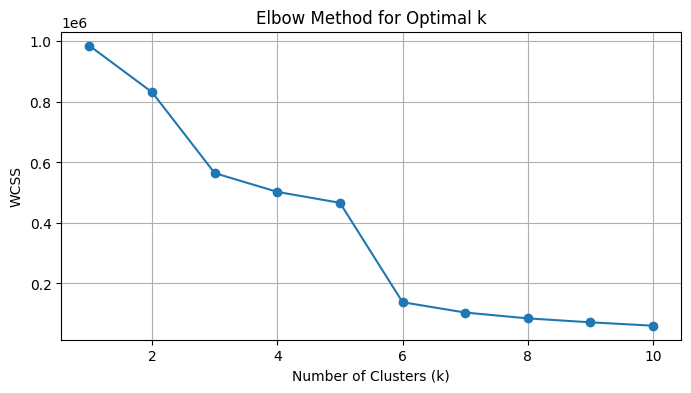

In [14]:
from sklearn.cluster import KMeans

# symbol 컬럼 제외하고 정규화
X_cluster = StandardScaler().fit_transform(df_features.drop(columns=['symbol', 'open_time']))

# WCSS 저장
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# 시각화
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


K를 6으로 설정할 경우, 일부 소수 데이터에만 클러스터가 할당되어 클래스 불균형이 과도하게 발생하였음.

k를 4로 할 경우에도 적절한 클러스터 분류가 되지 않았음.

이에 따라 클러스터 간 균형성과 해석 가능성을 고려하여 최종적으로 K=5를 선정하였음.

k=5로 설정

In [15]:
# KMeans 
from sklearn.cluster import KMeans

X_cluster = StandardScaler().fit_transform(df_features.drop(columns=['symbol', 'open_time']))
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_cluster)

df_features['cluster'] = labels


In [16]:
df_features

,price_change,vol_z,volatility,symbol,open_time,cluster
1,0.015141,-0.258608,0.011737,1INCH-BTC,2022-10-07 13:07:00,0
2,0.040769,-0.256556,0.015064,1INCH-BTC,2022-10-07 13:51:00,0
3,0.006051,-0.256269,0.019751,1INCH-BTC,2022-10-07 13:52:00,0
4,0.001899,-0.255874,0.022770,1INCH-BTC,2022-10-07 13:53:00,2
5,0.024960,-0.254739,0.034123,1INCH-BTC,2022-10-07 13:54:00,2
...,...,...,...,...,...,...
545529,0.029079,-0.252783,0.015393,ZRX-USDT,2022-11-15 16:03:00,0
545530,0.010466,-0.253496,0.013089,ZRX-USDT,2022-11-15 16:08:00,0
545531,-0.001036,-0.252835,0.009399,ZRX-USDT,2022-11-15 16:15:00,0
545532,-0.009331,-0.254461,0.010892,ZRX-USDT,2022-11-15 16:19:00,0


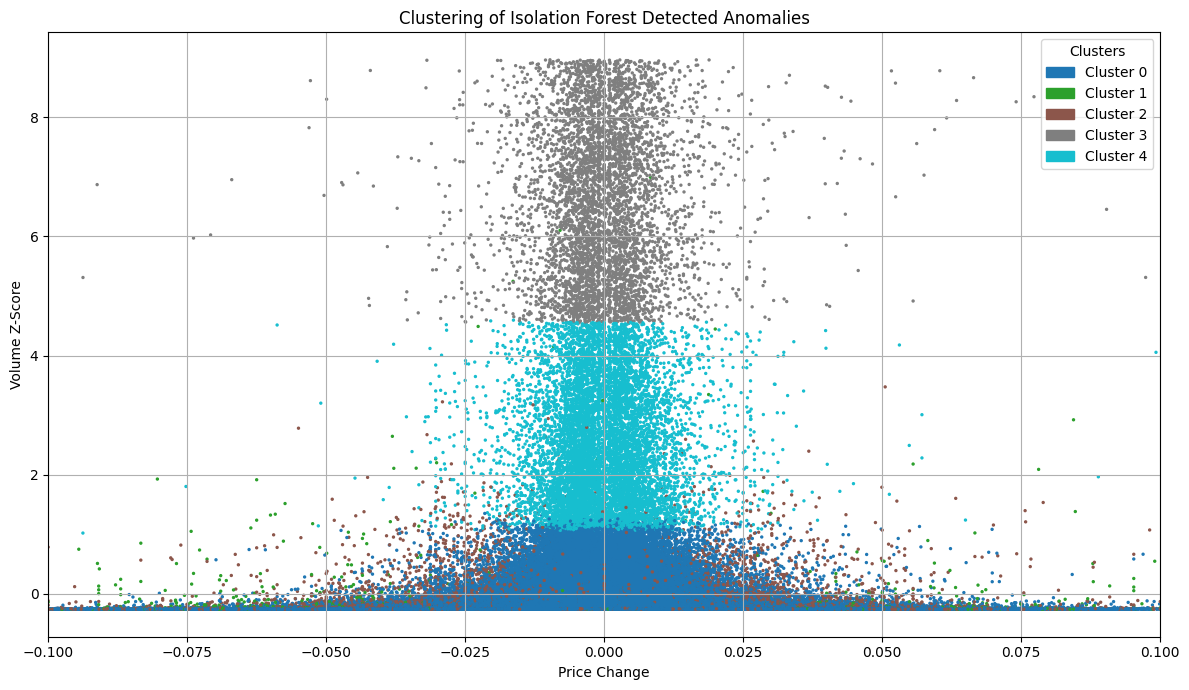

In [17]:
import matplotlib.patches as mpatches

plt.figure(figsize=(12, 7))

# 산점도 그리기
scatter = plt.scatter(
    df_features['price_change'],
    df_features['vol_z'],
    c=df_features['cluster'],
    cmap='tab10',
    s=2
)

# 클러스터 고유 값 추출
unique_clusters = sorted(df_features['cluster'].unique())

# scatter에서 컬러 매핑 얻기
colors = scatter.cmap(scatter.norm(unique_clusters))

# 범례 생성 (색상 자동 매핑)
legend_patches = [
    mpatches.Patch(color=colors[i], label=f'Cluster {c}')
    for i, c in enumerate(unique_clusters)
]

plt.legend(handles=legend_patches, title='Clusters', loc='upper right')
plt.xlabel('Price Change')
plt.ylabel('Volume Z-Score')
plt.title('Clustering of Isolation Forest Detected Anomalies')
plt.grid(True)
plt.xlim(-0.1, 0.1)  #  x축 범위 넓게
plt.tight_layout()
plt.show()


In [18]:
# 클러스터별 개수 출력
cluster_counts = df_features['cluster'].value_counts().sort_index()
print(cluster_counts)


cluster
0    265873
1      1985
2     46000
3      5253
4      9435
Name: count, dtype: int64


In [19]:
df_features.groupby('cluster')[['price_change', 'vol_z', 'volatility']].mean()

,price_change,vol_z,volatility
cluster,,,
0,387.365997,-0.183591,0.012227
1,32.481640,-0.142942,0.099293
2,10.012279,-0.201446,0.030680
3,-0.000560,6.615293,0.005216
4,0.001861,2.502631,0.006390


클러스터 해석

(0)잠복형: 외형적으로 미미하지만 이상치로 판단된 거래 (이상감지기에는 포착되지만 눈에는 잘 띄지 않음)

(1)가격 이탈형: 가격 하락과 함께 이탈하는 듯한 거래 패턴

(2)충격형: 가격의 급격한 변화 중심의 단기 이상 거래

(3)매집형: 거래량은 높으나 가격 변화는 미미한 반복 매매 형태 → 청산/매집 시도 가능

(4)은밀형: 가격은 조용히, 거래량방향성은 조금씩 누적 → 인위적 유입 가능성


코인 간 전이 분석 

In [93]:
!pip install networkx

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
df_features

,price_change,vol_z,volatility,symbol,open_time,cluster
1,0.015141,-0.258608,0.011737,1INCH-BTC,2022-10-07 13:07:00,0
2,0.040769,-0.256556,0.015064,1INCH-BTC,2022-10-07 13:51:00,0
3,0.006051,-0.256269,0.019751,1INCH-BTC,2022-10-07 13:52:00,0
4,0.001899,-0.255874,0.022770,1INCH-BTC,2022-10-07 13:53:00,2
5,0.024960,-0.254739,0.034123,1INCH-BTC,2022-10-07 13:54:00,2
...,...,...,...,...,...,...
545529,0.029079,-0.252783,0.015393,ZRX-USDT,2022-11-15 16:03:00,0
545530,0.010466,-0.253496,0.013089,ZRX-USDT,2022-11-15 16:08:00,0
545531,-0.001036,-0.252835,0.009399,ZRX-USDT,2022-11-15 16:15:00,0
545532,-0.009331,-0.254461,0.010892,ZRX-USDT,2022-11-15 16:19:00,0


In [21]:
from datetime import timedelta
import networkx as nx

# 시간 순 정렬
df_features = df_features.sort_values('open_time').reset_index(drop=True)

edges = []
time_threshold = timedelta(minutes=5)  # 5분 이내면 전이 간선으로 간주

for i in range(len(df_features) - 1):
    curr = df_features.iloc[i]
    next_ = df_features.iloc[i + 1]

    # 서로 다른 코인이고 시간차가 짧을 때
    if curr['symbol'] != next_['symbol']:
        if (next_['open_time'] - curr['open_time']) <= time_threshold:
            edges.append((curr['symbol'], next_['symbol']))

# 네트워크 생성
G = nx.DiGraph()
G.add_edges_from(edges)


In [22]:
from collections import Counter

# 전이 간선 등장 횟수 세기
edge_counts = Counter(edges)
edge_counts

Counter({('LTO-BTC', 'LTO-USDT'): 367,
         ('LTO-USDT', 'LTO-BTC'): 338,
         ('FTT-BNB', 'FTT-BTC'): 244,
         ('VIB-BTC', 'VIB-ETH'): 233,
         ('XRPDOWN-USDT', 'QLC-BTC'): 228,
         ('LINKDOWN-USDT', 'LINKUP-USDT'): 228,
         ('VIB-ETH', 'VIB-BTC'): 226,
         ('VIDT-BUSD', 'VIDT-BTC'): 221,
         ('NULS-BTC', 'NULS-USDT'): 217,
         ('QLC-BTC', 'XRPDOWN-USDT'): 212,
         ('LINKDOWN-USDT', 'XRPDOWN-USDT'): 212,
         ('FTT-BTC', 'FTT-BNB'): 207,
         ('VIDT-BTC', 'VIDT-BUSD'): 201,
         ('REEF-BUSD', 'REEF-USDT'): 200,
         ('NULS-USDT', 'NULS-BTC'): 194,
         ('LINKUP-USDT', 'LINKDOWN-USDT'): 189,
         ('XRPDOWN-USDT', 'MDX-USDT'): 189,
         ('XRPDOWN-USDT', 'QKC-BTC'): 188,
         ('XRPDOWN-USDT', 'LINKDOWN-USDT'): 187,
         ('NBS-USDT', 'TCT-USDT'): 187,
         ('OAX-BTC', 'QLC-BTC'): 185,
         ('QLC-BTC', 'OAX-BTC'): 184,
         ('QKC-BTC', 'XRPDOWN-USDT'): 183,
         ('MDX-USDT', 'XRPDOWN-USDT'):

C:\Users\USER\AppData\Local\Temp\ipykernel_3436\2704431111.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


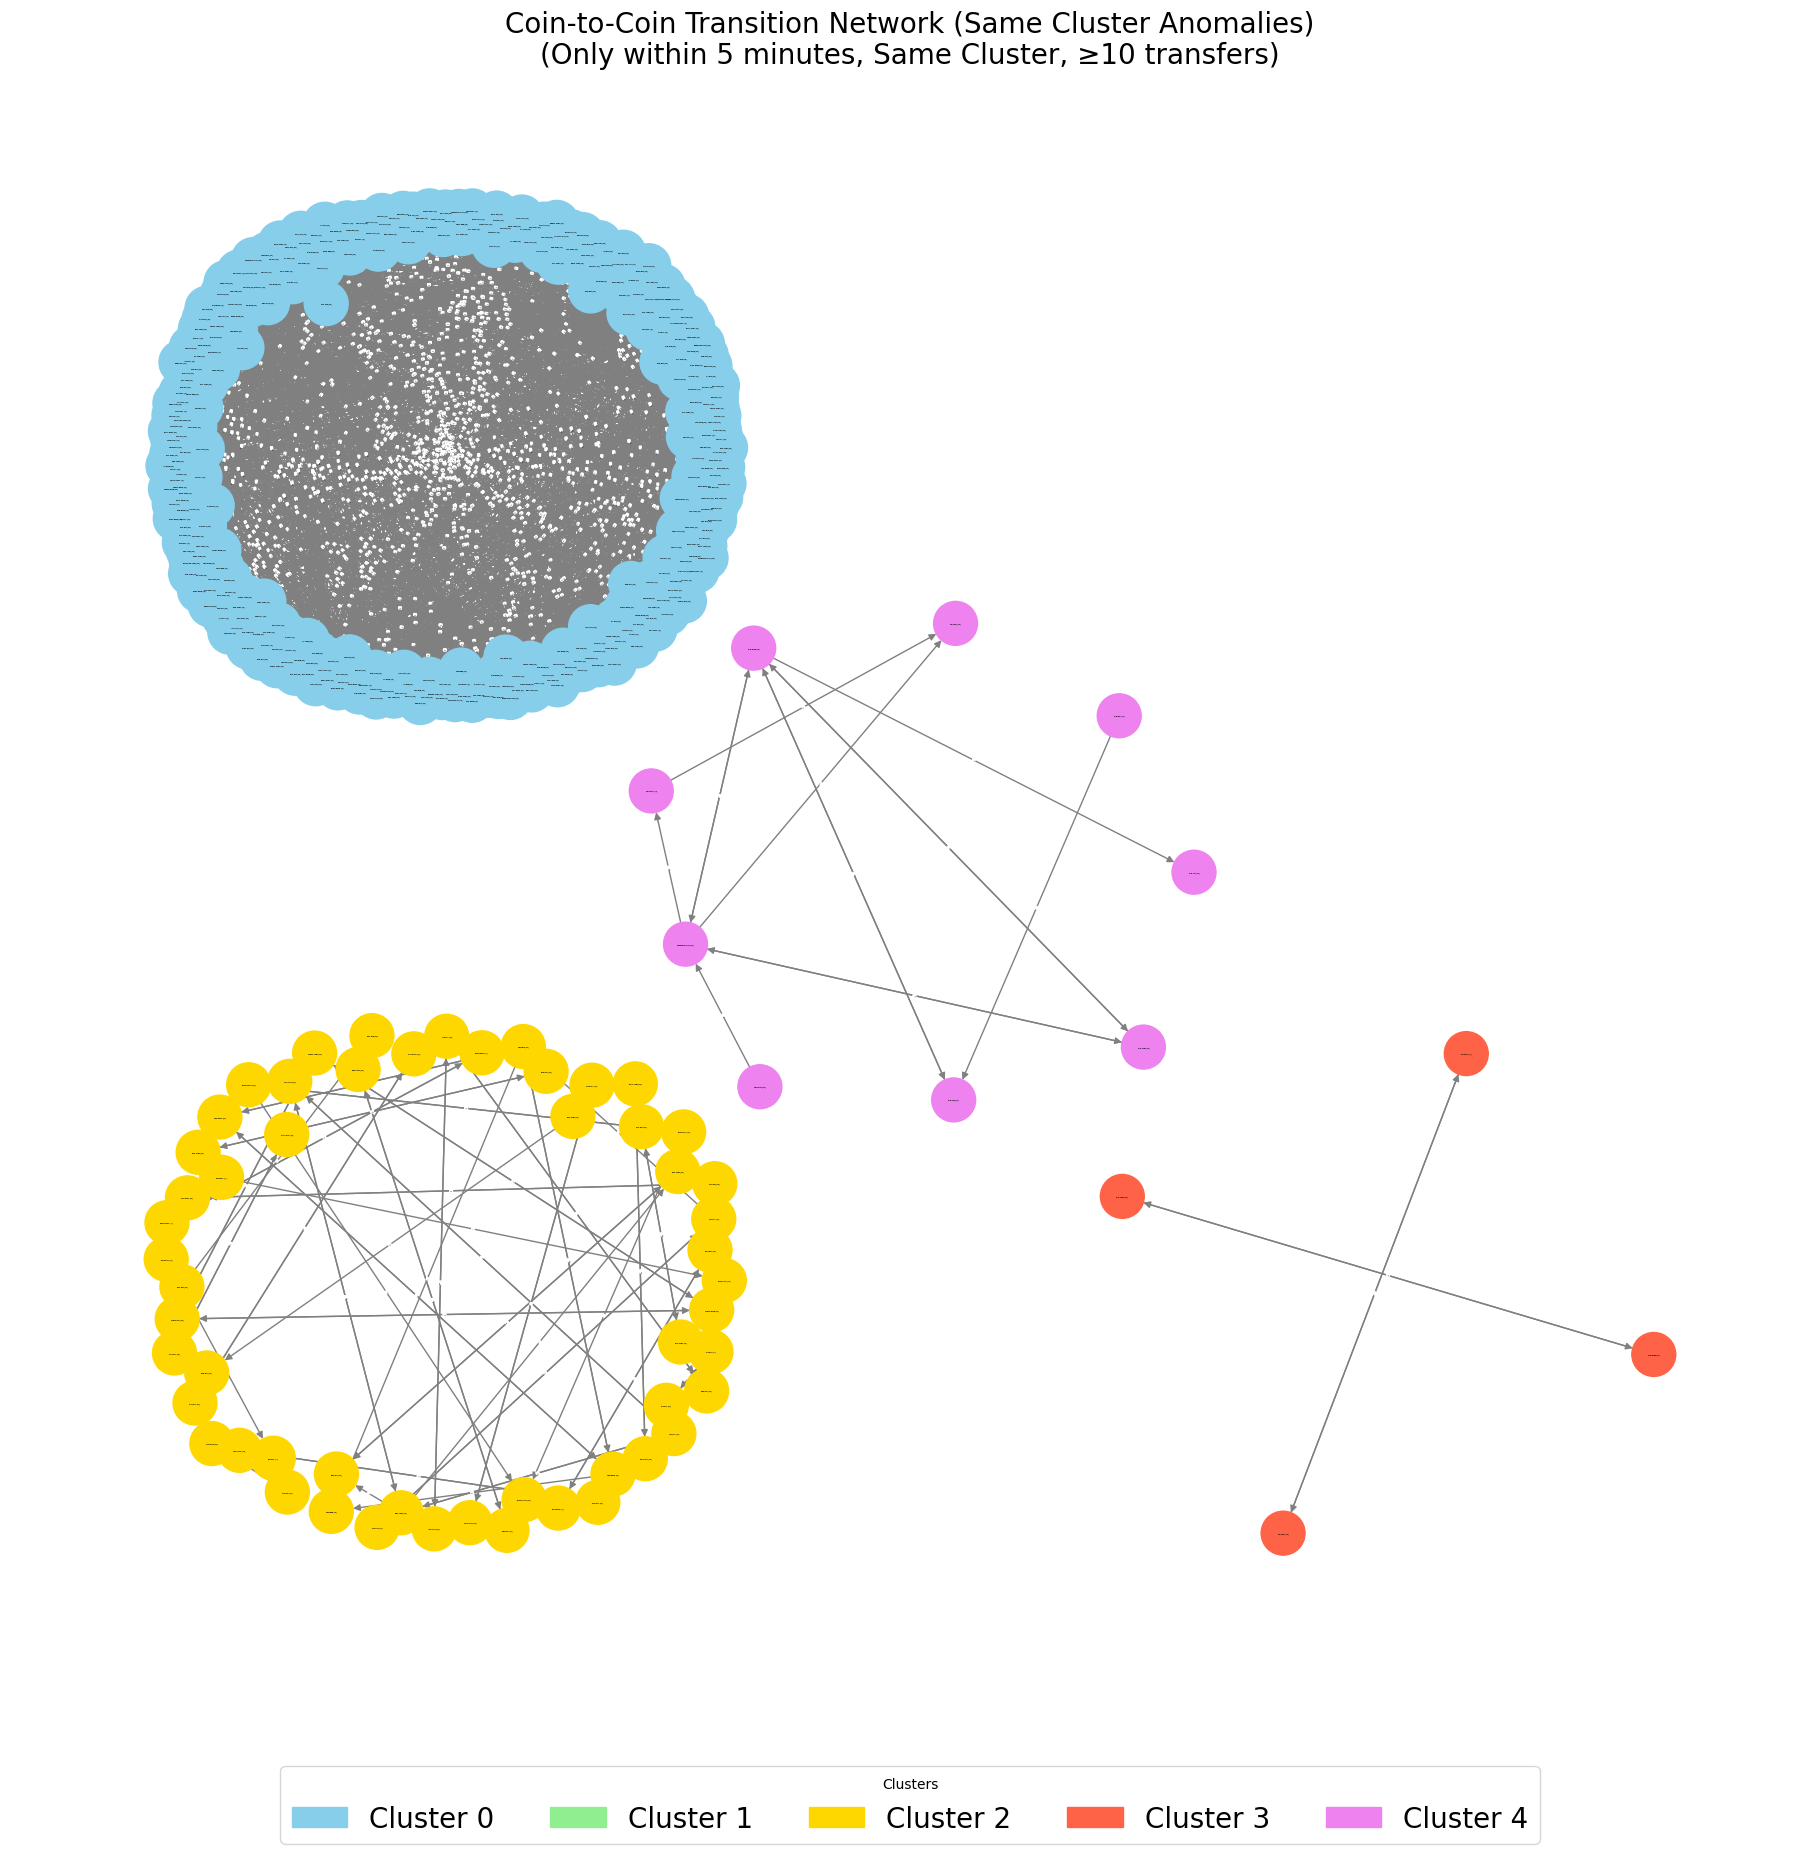

In [23]:
import networkx as nx
from datetime import timedelta
from collections import Counter
import matplotlib.patches as mpatches

# 클러스터 색상 지정 (5개)
cluster_colors = {0: 'skyblue', 1: 'lightgreen', 2: 'gold', 3: 'tomato', 4: 'violet'}

def get_cluster(node):
    return int(node.split("(C")[-1].replace(")", ""))

# 전이 간선 생성
df_features = df_features.sort_values('open_time').reset_index(drop=True)
time_threshold = timedelta(minutes=5)
edges_same_cluster = []

for i in range(len(df_features) - 1):
    curr = df_features.iloc[i]
    next_ = df_features.iloc[i + 1]
    
    if curr['symbol'] != next_['symbol'] and curr['cluster'] == next_['cluster']:
        if (next_['open_time'] - curr['open_time']) <= time_threshold:
            edges_same_cluster.append((f"{curr['symbol']} (C{curr['cluster']})",
                                       f"{next_['symbol']} (C{next_['cluster']})"))

# 전이 횟수 집계 후 필터링 (≥ 10)
edge_counts = Counter(edges_same_cluster)
edge_counts = {edge: count for edge, count in edge_counts.items() if count >= 10}

# 네트워크 생성
G = nx.DiGraph()
for edge, count in edge_counts.items():
    G.add_edge(edge[0], edge[1], weight=count)

node_clusters = {node: get_cluster(node) for node in G.nodes()}
node_colors = [cluster_colors[get_cluster(node)] for node in G.nodes()]

# 클러스터별 오프셋 지정 (5방향)
offsets = {
    0: (-5, 5),
    1: (5, 5),
    2: (-5, -5),
    3: (5, -5),
    4: (0, 0)  
}

# 클러스터별 그래프 분리 및 위치 설정
subgraphs = {c: G.subgraph([n for n in G.nodes() if node_clusters[n] == c]) for c in range(5)}
sub_positions = {}

for c, sg in subgraphs.items():
    sub_pos = nx.spring_layout(sg, seed=42, k=20, scale=3)
    ox, oy = offsets[c]
    for n, (x, y) in sub_pos.items():
        sub_positions[n] = (x + ox, y + oy)

# 시각화
plt.figure(figsize=(18, 16))
nx.draw(G, pos=sub_positions, with_labels=True,
        node_color=node_colors, node_size=1000,
        edge_color='gray', font_weight='bold', font_size=0)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos=sub_positions, edge_labels=edge_labels, font_size=0)

handles = [mpatches.Patch(color=color, label=f"Cluster {i}") for i, color in cluster_colors.items()]
plt.legend(handles=handles, title="Clusters", loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=20)

plt.title("Coin-to-Coin Transition Network (Same Cluster Anomalies)\n(Only within 5 minutes, Same Cluster, ≥10 transfers)", fontsize=20)
plt.axis('off')
plt.tight_layout()
plt.show()

동일 클러스터 내에서 5분 이내 다른 코인으로의 이상 거래 전이가 다수 포착됨

Cluster 0과 2는 간선이 상대적으로 많아, 클러스터 내에서 이상 거래 패턴이 확산되는 양상이 두드러짐

이러한 전이 패턴은 다수의 코인에 걸친 반복적 이상 거래 흐름을 의미하며, 
     단순 우연보다는 자동화된 알고리즘 또는   
     연계된 거래 활동일 가능성 시사함


다른 클러스터 포함

C:\Users\USER\AppData\Local\Temp\ipykernel_3436\3618895818.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


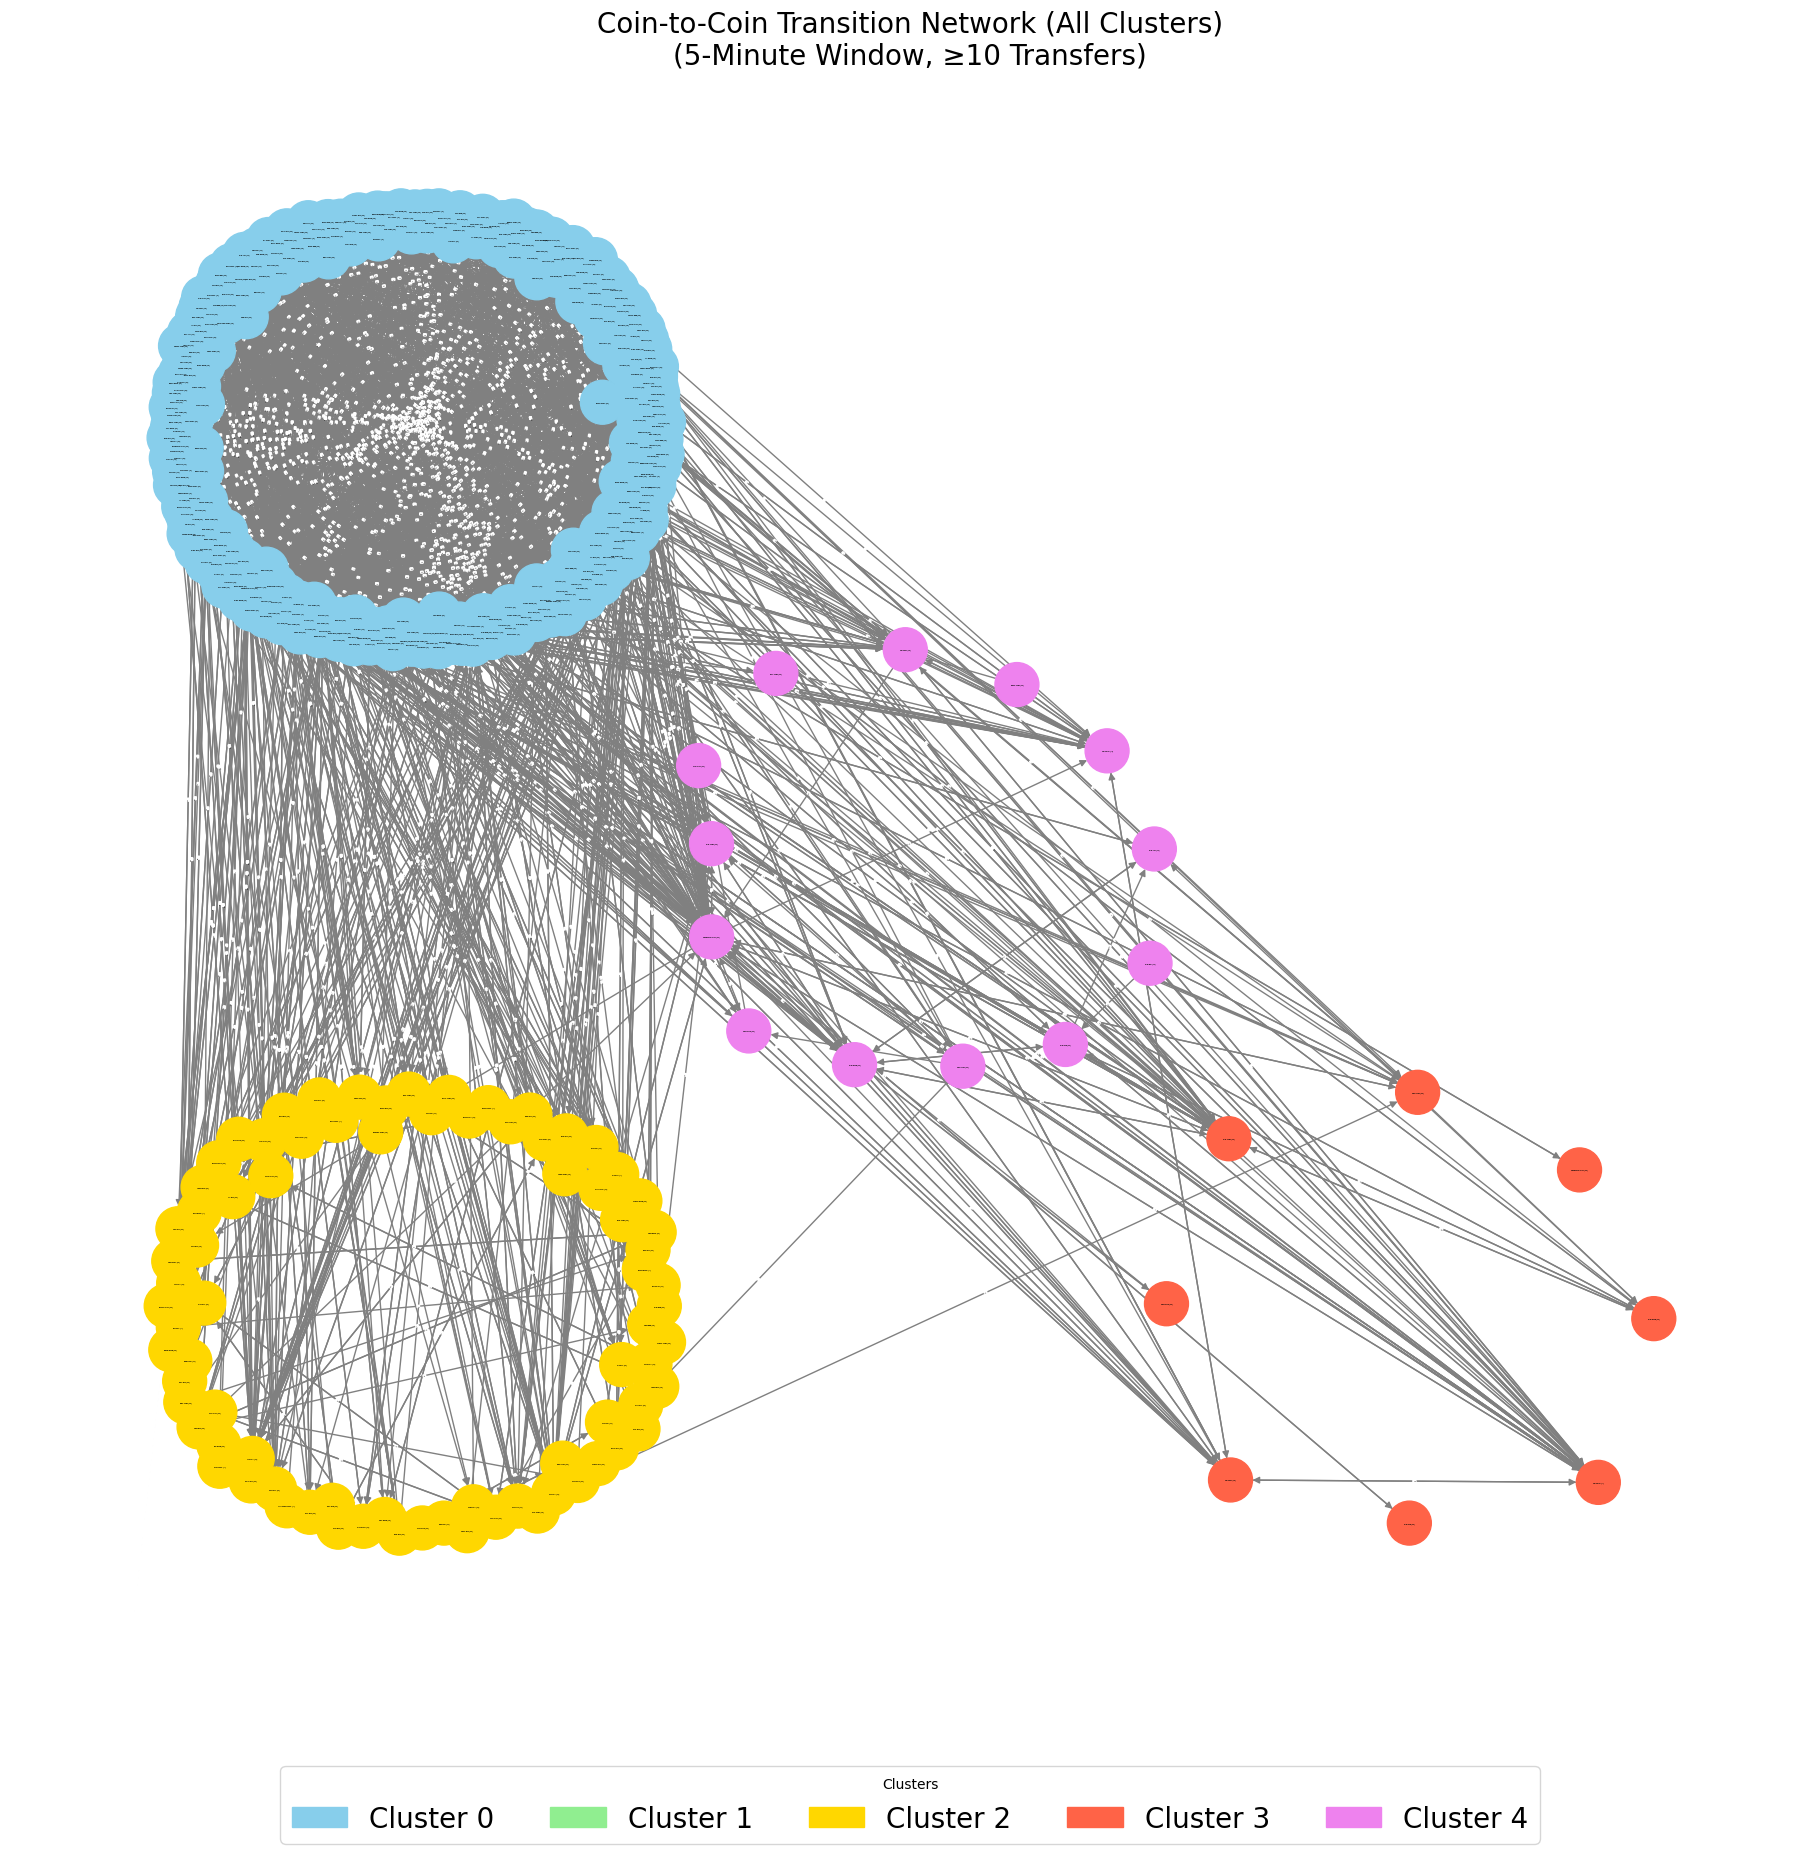

In [24]:
# 클러스터 색상 지정 (5개개)
cluster_colors = {0: 'skyblue', 1: 'lightgreen', 2: 'gold', 3: 'tomato', 4: 'violet'}

def get_cluster(node):
    return int(node.split("(C")[-1].replace(")", ""))

# 전이 간선 생성
df_features = df_features.sort_values('open_time').reset_index(drop=True)
time_threshold = timedelta(minutes=5)
edges_same_cluster = []

for i in range(len(df_features) - 1):
    curr = df_features.iloc[i]
    next_ = df_features.iloc[i + 1]

    # 클러스터 관계없이 다른 코인 + 5분 이내 조건만 적용
    if curr['symbol'] != next_['symbol']:
        if (next_['open_time'] - curr['open_time']) <= time_threshold:
            edges_same_cluster.append((f"{curr['symbol']} (C{curr['cluster']})",
                                       f"{next_['symbol']} (C{next_['cluster']})"))

# 전이 횟수 집계 후 필터링 (≥ 10)
edge_counts = Counter(edges_same_cluster)
edge_counts = {edge: count for edge, count in edge_counts.items() if count >= 10}

# 네트워크 생성
G = nx.DiGraph()
for edge, count in edge_counts.items():
    G.add_edge(edge[0], edge[1], weight=count)

node_clusters = {node: get_cluster(node) for node in G.nodes()}
node_colors = [cluster_colors[get_cluster(node)] for node in G.nodes()]

# 클러스터별 그래프 분리
subgraphs = {c: G.subgraph([n for n in G.nodes() if node_clusters[n] == c]) for c in range(5)}
sub_positions = {}

# 클러스터별 오프셋 (5개 배치)
offsets = {
    0: (-40, 40),
    1: (40, 40),
    2: (-40, -40),
    3: (40, -40),
    4: (0, 0)  # 중앙 배치
}

# 클러스터별 spring layout 계산 후 위치 조정
for c, sg in subgraphs.items():
    sub_pos = nx.spring_layout(sg, seed=42, k=150, scale=20)
    ox, oy = offsets[c]
    for n, (x, y) in sub_pos.items():
        sub_positions[n] = (x + ox, y + oy)

# 시각화
plt.figure(figsize=(18, 16))
nx.draw(G, pos=sub_positions, with_labels=True,
        node_color=node_colors, node_size=1000,
        edge_color='gray', font_weight='bold', font_size=0, arrows=True)

# 간선 라벨 (weight)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos=sub_positions, edge_labels=edge_labels, font_size=0)

# 범례 생성
handles = [mpatches.Patch(color=color, label=f"Cluster {i}") for i, color in cluster_colors.items()]
plt.legend(handles=handles, title="Clusters", loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=20)

# 제목 및 레이아웃
plt.title("Coin-to-Coin Transition Network (All Clusters)\n(5-Minute Window, ≥10 Transfers)", fontsize=20)
plt.axis('off')
plt.tight_layout()
plt.show()

이상 클러스터의 영향력 정량화 

In [25]:
edges_same_cluster = []
for i in range(len(df_features) - 1):
    curr = df_features.iloc[i]
    next_ = df_features.iloc[i + 1]

    if curr['symbol'] != next_['symbol']:
        if (next_['open_time'] - curr['open_time']) <= timedelta(minutes=5):
            # 클러스터 포함 노드명
            from_node = f"{curr['symbol']} (C{curr['cluster']})"
            to_node = f"{next_['symbol']} (C{next_['cluster']})"
            edges_same_cluster.append((from_node, to_node))

edge_counts = Counter(edges_same_cluster)
edge_counts = {edge: count for edge, count in edge_counts.items() if count >= 10}

G = nx.DiGraph()
for edge, count in edge_counts.items():
    G.add_edge(edge[0], edge[1], weight=count)


In [26]:
from collections import defaultdict

# 클러스터별 전이 유발 횟수 저장용
cluster_transfer_count = defaultdict(int)

def get_cluster(node):
    return int(node.split("(C")[-1].replace(")", "").strip())

# 간선 반복 → from_node 기준 클러스터별 집계
for from_node, to_node in G.edges():
    weight = G[from_node][to_node].get('weight', 1)
    from_cluster = get_cluster(from_node)
    cluster_transfer_count[from_cluster] += weight

# 결과 출력
print("=== 클러스터별 총 전이 유발 횟수 ===")
for cluster, total_transfer in sorted(cluster_transfer_count.items(), key=lambda x: x[1], reverse=True):
    print(f"Cluster {cluster}: {total_transfer}")


=== 클러스터별 총 전이 유발 횟수 ===
Cluster 0: 68385
Cluster 2: 4246
Cluster 4: 2752
Cluster 3: 1195


In [27]:
cluster_counts 

cluster
0    265873
1      1985
2     46000
3      5253
4      9435
Name: count, dtype: int64

In [28]:
print("=== 클러스터별 전이 유발 횟수 & 전이율 ===")

for cluster, total_transfer in sorted(cluster_transfer_count.items(), key=lambda x: x[1], reverse=True):
    count = cluster_counts.get(cluster, 1)  # 0으로 나누는 것 방지
    rate = total_transfer / count
    print(f"Cluster {cluster}: 전이 수 = {total_transfer:6d} / 소속 노드 수 = {count:6d} → 전이율 = {rate:.4f}")


=== 클러스터별 전이 유발 횟수 & 전이율 ===
Cluster 0: 전이 수 =  68385 / 소속 노드 수 = 265873 → 전이율 = 0.2572
Cluster 2: 전이 수 =   4246 / 소속 노드 수 =  46000 → 전이율 = 0.0923
Cluster 4: 전이 수 =   2752 / 소속 노드 수 =   9435 → 전이율 = 0.2917
Cluster 3: 전이 수 =   1195 / 소속 노드 수 =   5253 → 전이율 = 0.2275


| 클러스터 | 전이 수   | 노드 수    | 전이율        | 해석                              |
| ---- | ------ | ------- | ---------- | ------------------------------- |
| 0    | 68,500 | 265,873 | 0.2576     | 규모가 크고 영향력도 큼 (절대적 전이 중심)       |
| 4    | 2,769  | 9,435   | **0.2935** | 비율적으로 가장 전이 유발이 많은 **고위험 클러스터** |
| 2    | 4,077  | 46,000  | 0.0886     | 활동 적고 전이력 낮음                    |
| 3    | 1,126  | 5,253   | 0.2144     | 중간 위험 클러스터                      |


자주 연결되는 코인 시각화

C:\Users\USER\AppData\Local\Temp\ipykernel_3436\2534565109.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


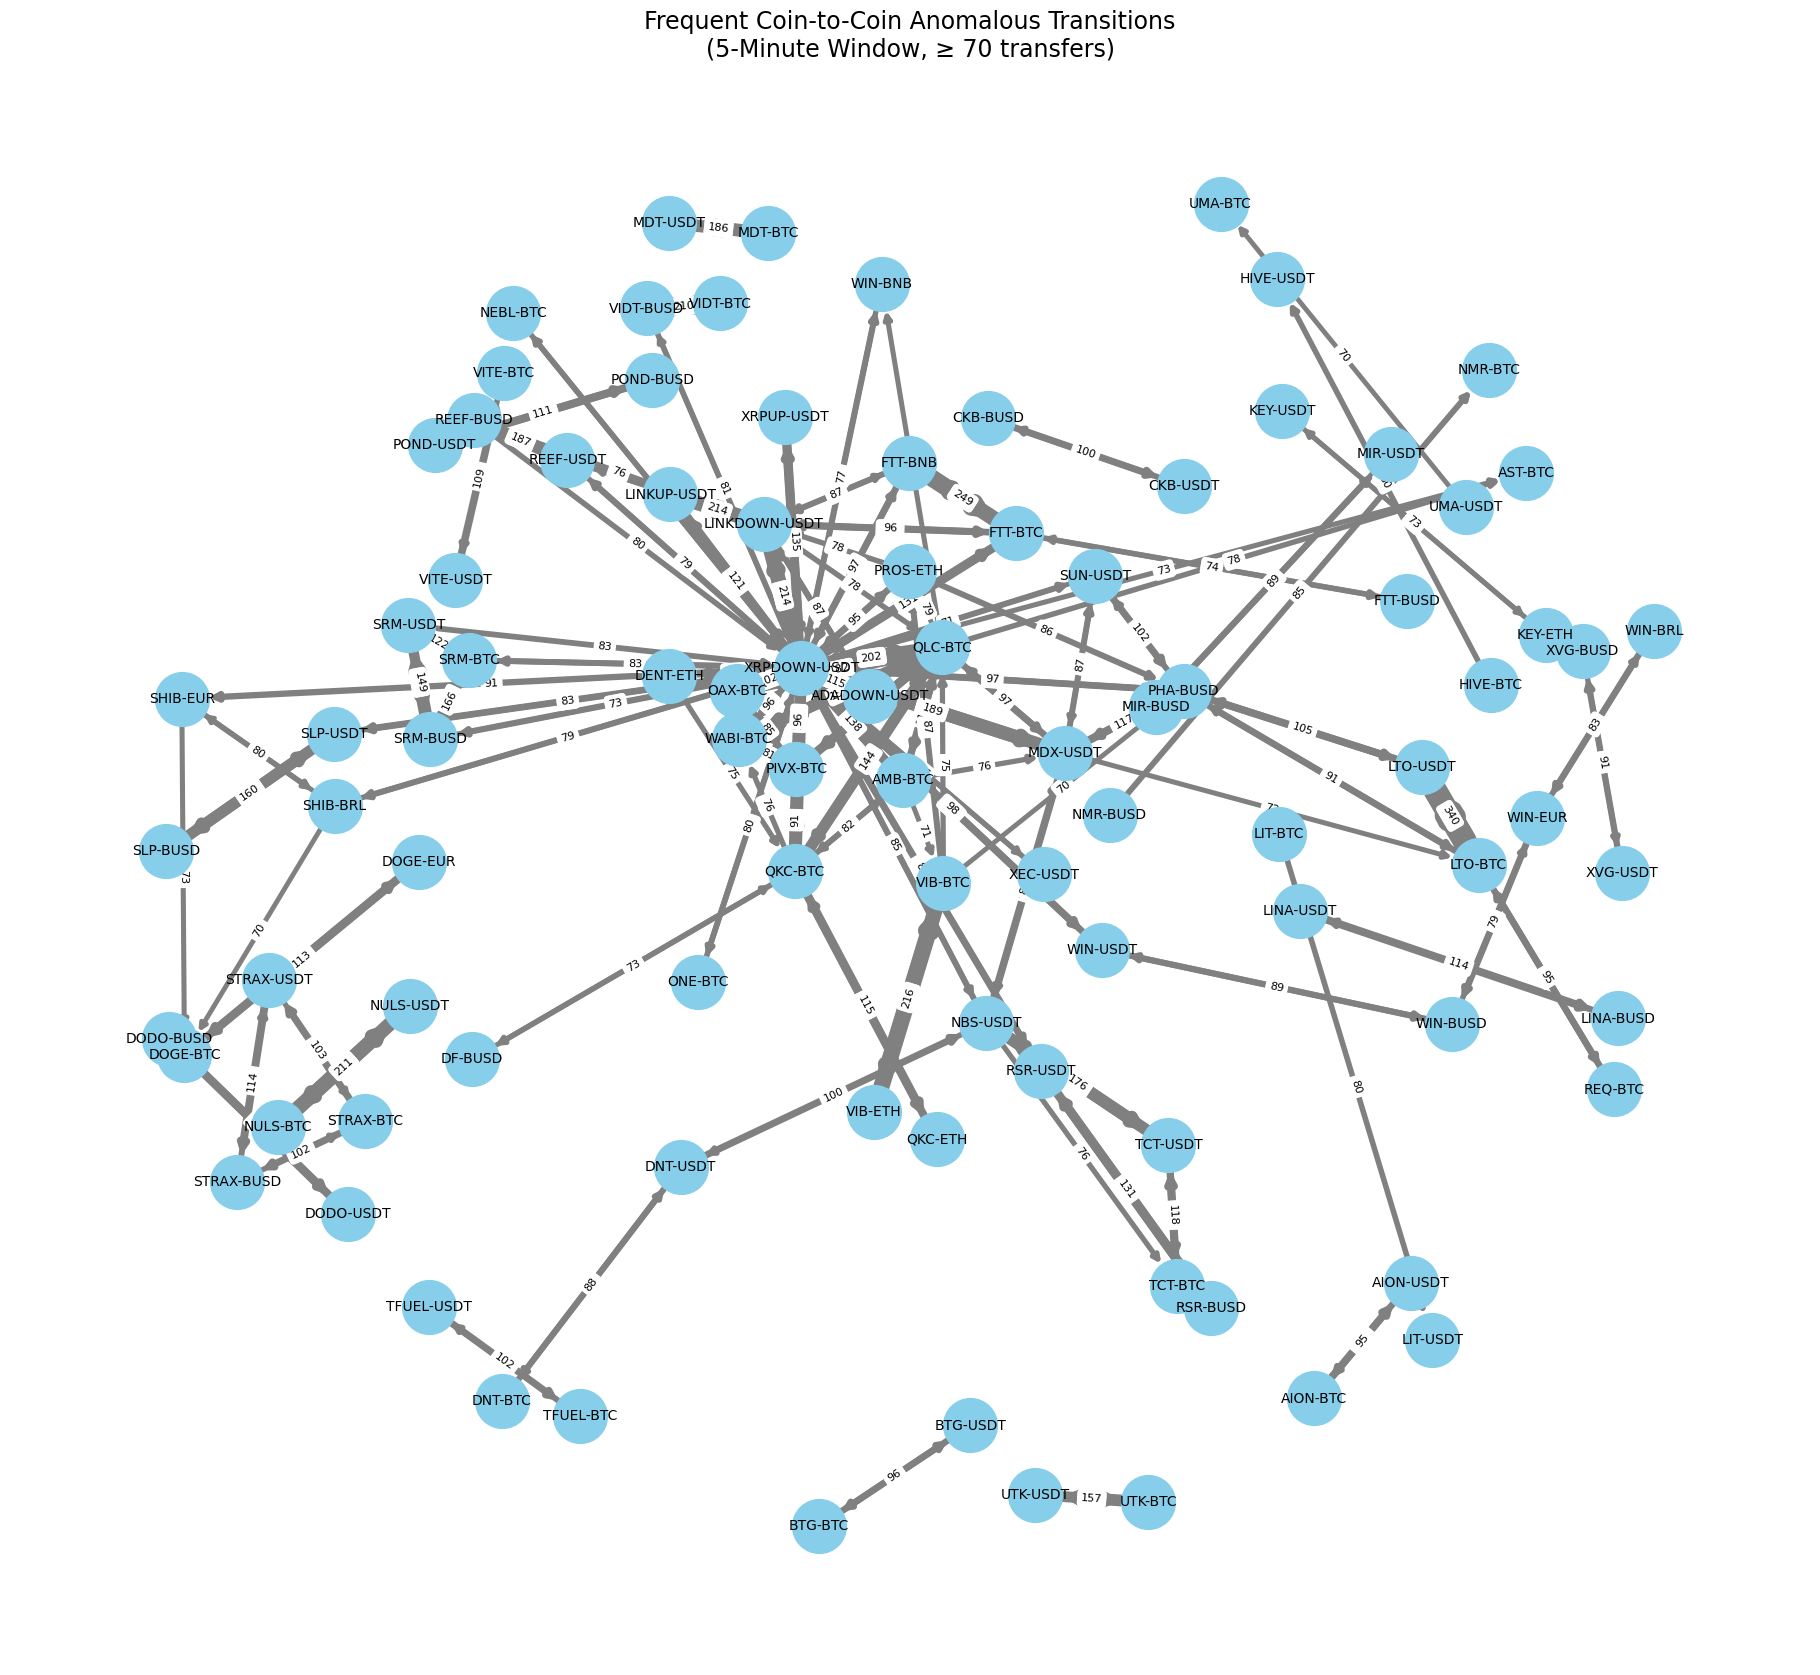

In [29]:
import matplotlib.cm as cm

# 전이 간선 생성 (코인 중심, 클러스터 무시)
df_sorted = df_features.sort_values('open_time').reset_index(drop=True)
time_threshold = timedelta(minutes=5)
edges_coin = []

for i in range(len(df_sorted) - 1):
    curr = df_sorted.iloc[i]
    next_ = df_sorted.iloc[i + 1]

    if curr['symbol'] != next_['symbol']:
        if (next_['open_time'] - curr['open_time']) <= time_threshold:
            edges_coin.append((curr['symbol'], next_['symbol']))

# 전이 횟수 집계 및 필터링 (≥ 70회)
edge_counts = Counter(edges_coin)
filtered_edges = {edge: cnt for edge, cnt in edge_counts.items() if cnt >= 70}

# 네트워크 생성
G = nx.DiGraph()
for (src, tgt), weight in filtered_edges.items():
    G.add_edge(src, tgt, weight=weight)


# 시각화
plt.figure(figsize=(18, 16))
pos = nx.spring_layout(G, k=2.0, seed=42)  

# 간선 굵기 = 전이 횟수
edge_weights = [G[u][v]['weight'] / 20 for u, v in G.edges()]
edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw(G, pos,
        with_labels=True,
        node_color='skyblue',  
        edge_color='gray',
        width=edge_weights,
        node_size=1500,
        font_size=10,
        arrows=True)


nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Frequent Coin-to-Coin Anomalous Transitions\n(5-Minute Window, ≥ 70 transfers)", fontsize=17)
plt.axis('off')
plt.tight_layout()
plt.show()




특정 이상 거래가 단발적이지 않고, 다른 코인으로 빠르게 전이되는 흐름을 형성함
    → 상호 연계된 거래 행위의 가능성을 
         시사함

중심 코인의 경우, 다른 이상 거래 발생을 유도하거나 촉진하는 중심 축으로 기능할 가능성이 있음 

연결이 많은 코인은 추가 모니터링, 심층 탐색 등에서 우선 순위로 고려 가능


Louvain 기반 커뮤니티 탐지 

In [30]:
!pip install python-louvain


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\USER\AppData\Local\Temp\ipykernel_3436\1532124394.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_coms)


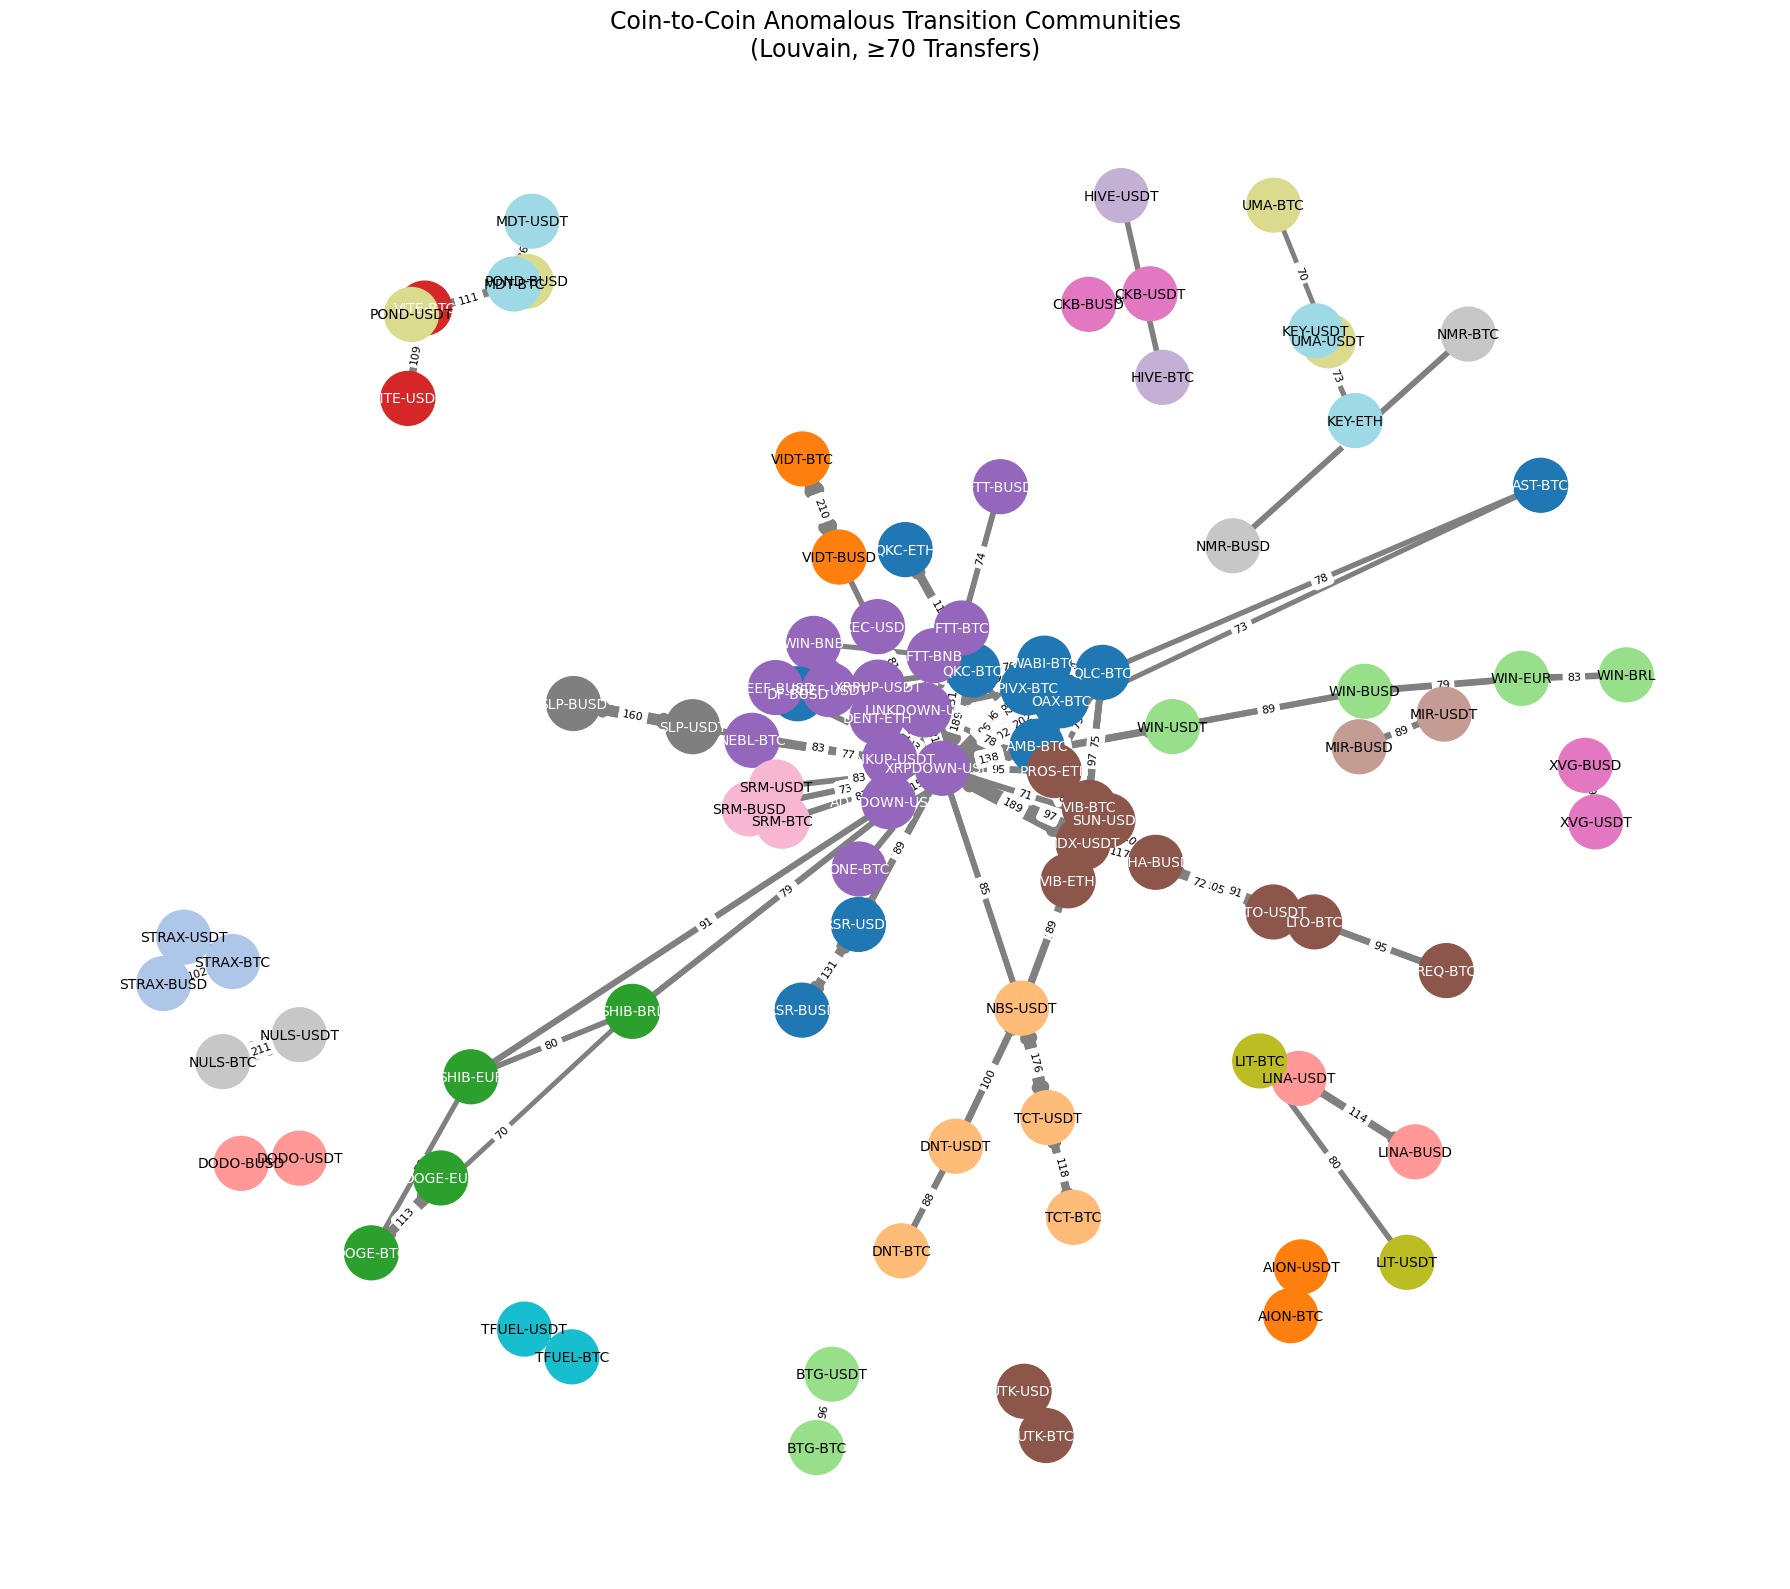

In [31]:
from community import community_louvain

# 방향 없는 그래프로 변환
G_undirected = G.to_undirected()

# Louvain 커뮤니티 탐지
partition = community_louvain.best_partition(G_undirected)

# 색상 매핑
num_coms = len(set(partition.values()))
cmap = cm.get_cmap('tab20', num_coms)
node_colors = [cmap(partition[n]) for n in G.nodes()]

# 대비를 고려한 글자색 설정 함수
def get_font_color(rgb_tuple):
    r, g, b = rgb_tuple[:3]
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if luminance > 0.5 else 'white'

font_colors = [get_font_color(c) for c in node_colors]

# 시각화
plt.figure(figsize=(18, 16))
pos = nx.spring_layout(G, seed=42, k=1)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_edges(G, pos,
                       width=[G[u][v]['weight'] / 20 for u, v in G.edges()],
                       edge_color='gray', arrows=True)

# 노드별 개별 폰트 색 적용
for i, node in enumerate(G.nodes()):
    nx.draw_networkx_labels(G, pos, labels={node: node},
                            font_color=font_colors[i], font_size=10)

# 간선 라벨
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Coin-to-Coin Anomalous Transition Communities\n(Louvain, ≥70 Transfers)", fontsize=17)
plt.axis('off')
plt.tight_layout()
plt.show()



단순 거래 시간 기반 네트워크 구조만으로도

이상 거래가 특정 코인 군집을 중심으로 형성됨을 확인.

이는 수동적 전이가 아닌 구조화된 이상 거래 연계의 가능성을 보여주며, 
커뮤니티 탐지를 통해 유사 행위 집단을 자동 식별할 수 있음을 시사함.


네트워크 분석

In [32]:
merged = pd.merge(df_features, iso_anomalies, on=['symbol', 'open_time'])
print(merged.head())


   price_change     vol_z  volatility     symbol  open_time  cluster  \
0    379.641846 -0.201844    0.001362  TROY-USDT 2022-10-01        0   
1   1717.181885 -0.219579    0.001057  DENT-USDT 2022-10-01        0   
2      1.156522 -0.258739    0.006085    WAN-BTC 2022-10-01        0   
3     -0.999026 -0.258369    0.034260  STRAX-BTC 2022-10-01        2   
4      0.146000 -0.252634    0.003490  HBAR-USDT 2022-10-01        0   

       open      high       low     close         volume  quote_asset_volume  \
0  0.003672  0.003677  0.003672  0.003677  841620.000000         3092.008545   
1  0.000946  0.000946  0.000945  0.000945  579873.000000          548.427612   
2  0.000010  0.000010  0.000010  0.000010    1945.000000            0.019243   
3  0.000026  0.000027  0.000026  0.000027    7401.700195            0.197068   
4  0.057300  0.057400  0.057200  0.057300   92045.000000         5274.300293   

   number_of_trades  taker_buy_base_asset_volume  taker_buy_quote_asset_volume  
0    

파생변수 생성 코드

In [33]:
# 그룹 기준: 코인
grouped = merged.groupby('symbol')

# 기본 통계
mean_price_change = grouped['price_change'].mean()
price_change_std = grouped['price_change'].std()
mean_vol_z = grouped['vol_z'].mean()
trade_density = grouped['number_of_trades'].mean()

# 비율 계산
volatility_peak_ratio = grouped.apply(lambda x: (x['volatility'] > 0.02).mean())
aggressive_buy_ratio = grouped.apply(lambda x: (x['taker_buy_base_asset_volume'] / (x['volume'] + 1e-6)).mean())

# 클러스터 분석
dominant_cluster = grouped['cluster'].agg(lambda x: x.mode().iloc[0])
cluster_entropy = grouped['cluster'].apply(
    lambda x: -(x.value_counts(normalize=True) * np.log2(x.value_counts(normalize=True))).sum()
)


C:\Users\USER\AppData\Local\Temp\ipykernel_3436\2730597100.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volatility_peak_ratio = grouped.apply(lambda x: (x['volatility'] > 0.02).mean())
C:\Users\USER\AppData\Local\Temp\ipykernel_3436\2730597100.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggressive_buy_ratio = grouped.apply(lambda x: (x['taker_buy_base_asset_volume'] / (x['volume'] + 1e-6)).

최종 벡터 결합

In [34]:
coin_features = pd.DataFrame({
    'mean_price_change': mean_price_change,
    'price_change_std': price_change_std,
    'mean_vol_z': mean_vol_z,
    'volatility_peak_ratio': volatility_peak_ratio,
    'trade_density': trade_density,
    'aggressive_buy_ratio': aggressive_buy_ratio,
    'dominant_cluster': dominant_cluster,
    'cluster_entropy': cluster_entropy
}).reset_index()


In [35]:
coin_features.head(3)

,symbol,mean_price_change,price_change_std,mean_vol_z,volatility_peak_ratio,trade_density,aggressive_buy_ratio,dominant_cluster,cluster_entropy
0,1INCH-BTC,0.000594,0.020140,-0.257522,0.225806,179.387097,0.492982,0,0.740866
1,1INCH-BUSD,193.922012,1890.123506,-0.256727,0.200000,120.726316,0.520321,0,0.677769
2,1INCH-USDT,0.000469,0.030287,-0.252656,0.067416,227.516854,0.433500,0,0.356205


유사도 계산 + 네트워크 생성

In [36]:
# 평균값 계산
mean_std = coin_features['price_change_std'].mean()

# NaN 값 평균으로 대체
coin_features['price_change_std'] = coin_features['price_change_std'].fillna(mean_std)


In [37]:
from sklearn.metrics.pairwise import cosine_similarity

X = coin_features.drop('symbol', axis=1)
sim_matrix = cosine_similarity(X)


In [38]:
symbols = coin_features['symbol'].tolist()
G = nx.Graph()


In [39]:
# 이상치 수 기준 상위 100개 코인 추출
anomaly_counts = merged['symbol'].value_counts()
top_symbols = anomaly_counts.head(100).index.tolist()

# coin_features에서 해당 코인만 필터링
coin_top = coin_features[coin_features['symbol'].isin(top_symbols)].reset_index(drop=True)


In [40]:
from sklearn.metrics.pairwise import cosine_similarity

X = coin_top.drop('symbol', axis=1)
sim_matrix = cosine_similarity(X)
symbols = coin_top['symbol'].tolist()


In [41]:
G = nx.Graph()

# 노드 추가
for symbol in symbols:
    G.add_node(symbol)

# 엣지 추가 (유사도 기준)
threshold = 0.85
for i in range(len(symbols)):
    for j in range(i + 1, len(symbols)):
        sim = sim_matrix[i, j]
        if sim >= threshold:
            G.add_edge(symbols[i], symbols[j], weight=sim)


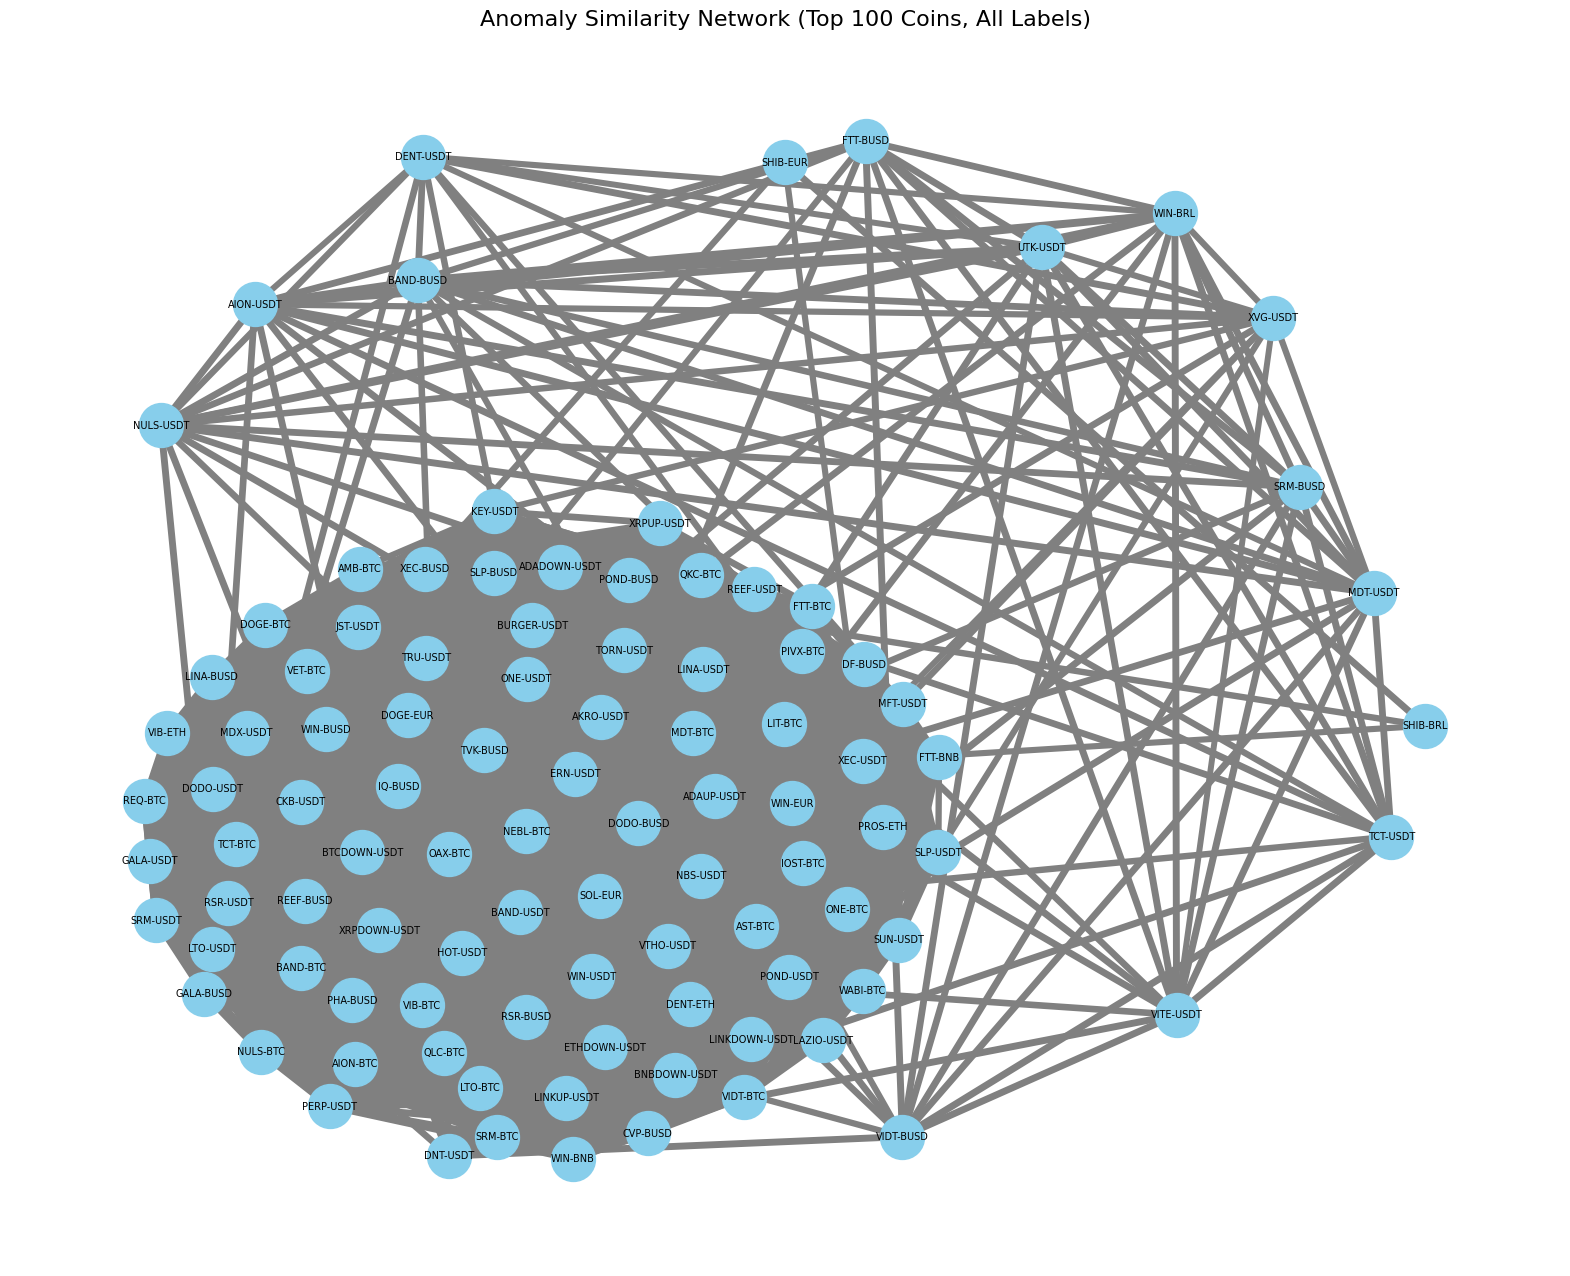

In [42]:
# 레이아웃 설정 
pos = nx.spring_layout(G, seed=42, k=2)  
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]

# 시각화
plt.figure(figsize=(20, 16))  
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=1000)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=weights)
nx.draw_networkx_labels(G, pos, font_size=7)  # 전체 라벨링

plt.title("Anomaly Similarity Network (Top 100 Coins, All Labels)", fontsize=16)
plt.axis('off')
plt.show()



다수의 코인들이 유사한 이상거래 특성을 기반으로 밀접하게 연결되어 있으며, 중심에 위치한 코인들은 서로 높은 유사성을 가짐

네트워크 중심성과 연결 밀도를 통해 주요 코인의 공통된 이상거래 패턴을 유추할 수 있음  

외곽에 위치한 일부 코인은 독립적이거나 특이한 이상 패턴을 보일 가능성이 있음 
